In [19]:
import pandas as pd
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## loading data

In [12]:
data_dict = pd.read_pickle('../data/san_tokens_PA_data_100.pkl')

In [18]:
pprint(data_dict.keys())

dict_keys(['frax-share', 'celer-network', 'blockv', 'altlayer', 'cyberconnect', 'polkastarter', 'huobi-token', 'neiro-eth', 'arb-a3s-protocol', 'xrp', 'quant', 'bitmart-token', 'milady-meme-coin', 'dextools', 'aethir', 'layerzero', 'enjin-coin', 'dora-factory', 'tokemak', 'blur-token', 'crypto-com-coin', 'chain', 'turbo', 'keep-network', 'the-root-network', 'chex-token', 'apex-token', 'feed-every-gorilla', 'gatechain-token', 'metisdao', 'superrare', 'cartesi', 'project-galaxy', 'rake-coin', 'katana-inu', 'dmail-network', 'department-of-government-efficiency-token', 'storj', 'koinos', 'niobium-coin', 'chronotech', 'ribbon-finance', 'firmachain', 'mileverse', 'ethereum', 'dkargo', 'rally', 'arkham', 'stake-dao', 'echelon-prime', 'wilder-world', 'assemble-protocol', 'pixels', 'liquity', 'curve', 'pepefork', 'wojak', 'prom', 'meme', 'api3', 'tenset', 'chromia', 'gems-vip', 'wax', 'wootrade', 'palm-ai', 'apecoin-ape', 'hackenai', 'altava', 'fox-token', 'clover', 'hippocrat', 'vaiot', 'usual

In [20]:
melon_df = data_dict['melon']

# EDA

In [22]:
melon_df

,daily_opening_price_usd,daily_high_price_usd,daily_low_price_usd,daily_closing_price_usd,daily_trading_volume_usd,daily_active_addresses,transactions_count,transaction_volume,transaction_volume_usd,volume_usd,circulation_1d,network_growth
timestamp,,,,,,,,,,,,
2020-01-11,3.458587,3.478930,3.336814,3.340178,127641.0,12.0,10.0,1421.665760,4845.216341,127641.0,737.734940,4.0
2020-01-12,3.336471,3.470913,3.331932,3.435283,128839.0,13.0,3.0,218.141043,739.287404,128839.0,76.990651,3.0
2020-01-13,3.452258,3.607953,3.290213,3.436187,178369.0,31.0,18.0,3312.941549,11291.462667,178369.0,1553.295926,7.0
2020-01-14,3.435363,3.942484,3.424660,3.903329,60136.0,22.0,9.0,2928.491062,10828.392783,60136.0,1602.806601,1.0
2020-01-15,3.919635,3.998575,3.734214,3.915292,47415.0,33.0,17.0,3574.435770,13931.539223,47415.0,1081.326209,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,20.694859,21.669518,20.322303,20.447107,3829207.0,39.0,23.0,7910.242465,165619.009269,3829207.0,6467.748237,9.0
2024-12-30,20.431950,21.301266,19.107502,19.528028,5367941.0,66.0,66.0,43786.820496,886343.831294,5367941.0,30783.916215,12.0
2024-12-31,19.535224,19.841866,18.595752,18.643923,3855737.0,35.0,15.0,7179.936362,138699.276584,3855737.0,4463.429994,3.0


In [21]:
print(melon_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1819 entries, 2020-01-11 to 2025-01-02
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_opening_price_usd   1819 non-null   float64
 1   daily_high_price_usd      1819 non-null   float64
 2   daily_low_price_usd       1819 non-null   float64
 3   daily_closing_price_usd   1819 non-null   float64
 4   daily_trading_volume_usd  1819 non-null   float64
 5   daily_active_addresses    1819 non-null   float64
 6   transactions_count        1819 non-null   float64
 7   transaction_volume        1819 non-null   float64
 8   transaction_volume_usd    1819 non-null   float64
 9   volume_usd                1819 non-null   float64
 10  circulation_1d            1819 non-null   float64
 11  network_growth            1819 non-null   float64
dtypes: float64(12)
memory usage: 184.7+ KB
None


### data checking

In [61]:
for k in data_dict:
    df = data_dict[k]
    default_shape = df.shape[0]
    without_dupl_shape = df.reset_index().drop_duplicates(subset='timestamp').shape[0]
    # duplicates checking
    if without_dupl_shape != default_shape:
        print(f'{k} | default shape: {default_shape} | after dropping duplicates shape: {without_dupl_shape}')

    

In [131]:
def eda(df: pd.DataFrame, key_name: str, show_plots=True):
    """
    EDA analysis
    """
    
    df = df.copy()
    df.reset_index(inplace=True)
    df.drop_duplicates(subset='timestamp', inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.sort_values('timestamp', inplace=True)
    df.set_index('timestamp', inplace=True, drop=True)


    stats_summary = {
        'token_name': key_name,
        'num_rows': len(df),
        'date_min': df.index.min(),
        'date_max': df.index.max()
    }

    # daily_closing_price_usd, daily_trading_volume_usd, daily_active_addresses
    stats_summary['mean_closing_price'] = df['daily_closing_price_usd'].mean()
    stats_summary['median_closing_price'] = df['daily_closing_price_usd'].median()
    stats_summary['mean_trading_volume'] = df['daily_trading_volume_usd'].mean()
    stats_summary['median_trading_volume'] = df['daily_trading_volume_usd'].median()
    stats_summary['mean_daily_active_addr'] = df['daily_active_addresses'].mean()
    stats_summary['median_daily_active_addr'] = df['daily_active_addresses'].median()
    
    if show_plots:

        plt.figure(figsize=(10, 4))
        plt.plot(df.index, df['daily_closing_price_usd'], label='Closing Price')
        plt.title(f'{key_name} - Closing Price over time')
        plt.xlabel('Date')
        plt.ylabel('Price, USD')
        plt.legend()
        plt.show()
        
        plt.figure(figsize=(10, 4))
        plt.plot(df.index, df['daily_trading_volume_usd'], label='Trading Volume', color='orange')
        plt.title(f'{key_name} - Trading Volume over time')
        plt.xlabel('Date')
        plt.ylabel('Volume, USD')
        plt.legend()
        plt.show()
        
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 1:
            corr_matrix = df[numeric_cols].corr()
            plt.figure(figsize=(12,5))
            sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
            plt.title(f'{key_name} - Correlation Matrix')
            plt.show()
    
    return stats_summary

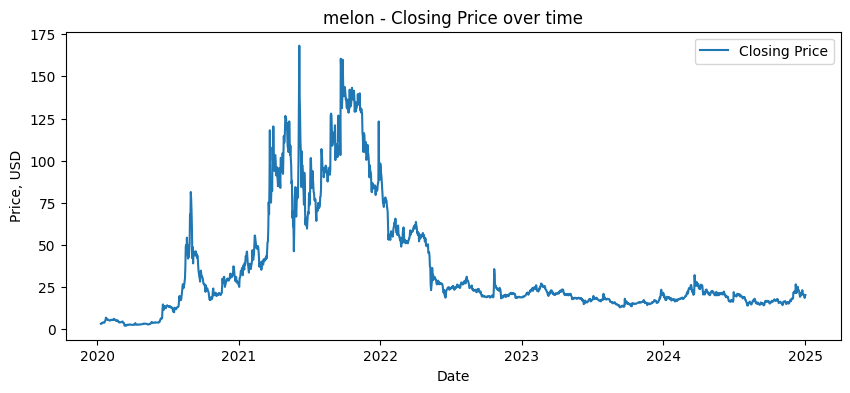

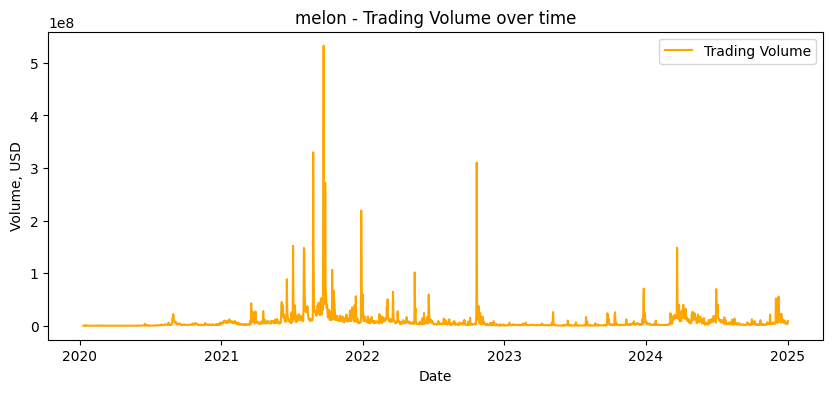

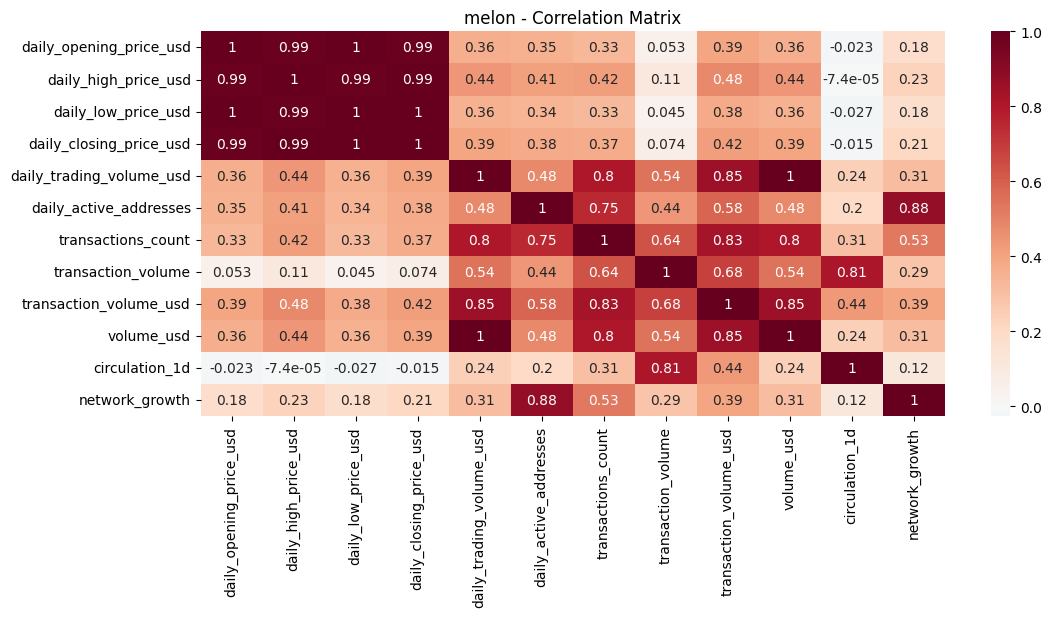

In [132]:
melon_df = data_dict['melon']
melon_stats = eda(df=melon_df, key_name='melon')

In [133]:

def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocessing input dataframe
    """
    df = df.copy()
    df.reset_index(inplace=True)
    if 'timestamp' not in df.columns:
        raise ValueError("input df has not contain timestamp col")
    
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df.dropna(subset=['timestamp'], inplace=True)
    df.sort_values('timestamp', inplace=True)
    df.set_index('timestamp', inplace=True, drop=True)
    
    # TODO filling missing values
    
    return df

In [134]:
all_summaries = []

for key, df_input in data_dict.items():
    df_input = preprocess_df(df_input)
    summary = eda(df_input, key, show_plots=False)
    all_summaries.append(summary)

df_summary = pd.DataFrame(all_summaries)
del all_summaries
del df_input
del summary
df_summary.shape

(100, 10)

In [135]:
df_summary

,token_name,num_rows,date_min,date_max,mean_closing_price,median_closing_price,mean_trading_volume,median_trading_volume,mean_daily_active_addr,median_daily_active_addr
0,frax-share,1819,2020-01-11,2025-01-02,6.602423,5.362420,1.953667e+07,12979436.0,232.322705,240.0
1,celer-network,1819,2020-01-11,2025-01-02,0.026159,0.016685,3.147185e+07,8009353.0,113.147334,98.0
2,blockv,1819,2020-01-11,2025-01-02,0.004865,0.002622,1.587400e+05,5813.0,25.572842,18.0
3,altlayer,687,2021-12-15,2025-01-02,0.123649,0.073178,3.985040e+07,7725913.0,1252.594801,192.0
4,cyberconnect,918,2021-12-15,2025-01-02,3.372610,3.109270,2.370415e+07,13771853.0,65.090513,50.0
...,...,...,...,...,...,...,...,...,...,...
95,lever,1819,2020-01-11,2025-01-02,0.001004,0.000000,8.951099e+06,0.0,40.804324,34.0
96,melon,1819,2020-01-11,2025-01-02,36.095071,21.588108,8.148728e+06,3207992.0,61.571743,45.0
97,matic-network,1819,2020-01-11,2025-01-02,0.732921,0.713703,5.291821e+08,313664955.0,2859.461792,2413.0
98,shiba-inu,1819,2020-01-11,2025-01-02,0.000012,0.000009,6.628543e+08,220646745.0,7434.347038,5067.0


In [138]:
data_dict['meme'].dropna()

,daily_opening_price_usd,daily_high_price_usd,daily_low_price_usd,daily_closing_price_usd,daily_trading_volume_usd,daily_active_addresses,transactions_count,transaction_volume,transaction_volume_usd,volume_usd,circulation_1d,network_growth
timestamp,,,,,,,,,,,,
2023-12-15,0.034968,0.036635,0.030891,0.030898,184570986.0,531.0,433.0,2.323459e+08,7.836954e+06,184570986.0,9.871724e+07,114.0
2023-12-16,0.030906,0.032992,0.030706,0.032491,92965249.0,433.0,353.0,1.668798e+08,5.344625e+06,92965249.0,7.731562e+07,89.0
2023-12-17,0.032494,0.033195,0.030652,0.030852,93992496.0,576.0,474.0,1.581477e+08,5.051138e+06,93992496.0,8.872010e+07,108.0
2023-12-18,0.030852,0.031286,0.027438,0.029107,112909647.0,449.0,368.0,2.354697e+08,6.800992e+06,112909647.0,1.005832e+08,103.0
2023-12-19,0.029122,0.031218,0.028953,0.030844,136308562.0,617.0,752.0,5.769894e+08,1.735999e+07,136308562.0,2.595497e+08,281.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,0.011212,0.011238,0.010529,0.010654,53878796.0,1406.0,950.0,3.557956e+08,3.894022e+06,53878796.0,1.604078e+08,400.0
2024-12-30,0.010653,0.011173,0.010485,0.010719,93370192.0,1263.0,854.0,7.116625e+08,7.732778e+06,93370192.0,2.897505e+08,475.0
2024-12-31,0.010719,0.010952,0.010236,0.010655,53377802.0,805.0,437.0,5.012737e+09,5.303769e+07,53377802.0,2.192573e+09,149.0


In [139]:
data_dict['meme']

,daily_opening_price_usd,daily_high_price_usd,daily_low_price_usd,daily_closing_price_usd,daily_trading_volume_usd,daily_active_addresses,transactions_count,transaction_volume,transaction_volume_usd,volume_usd,circulation_1d,network_growth
timestamp,,,,,,,,,,,,
2021-12-15,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-17,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-18,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-19,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-20,0.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,0.011212,0.011238,0.010529,0.010654,53878796.0,1406.0,950.0,3.557956e+08,3.894022e+06,53878796.0,1.604078e+08,400.0
2024-12-30,0.010653,0.011173,0.010485,0.010719,93370192.0,1263.0,854.0,7.116625e+08,7.732778e+06,93370192.0,2.897505e+08,475.0
2024-12-31,0.010719,0.010952,0.010236,0.010655,53377802.0,805.0,437.0,5.012737e+09,5.303769e+07,53377802.0,2.192573e+09,149.0
